In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
import warnings, os
warnings.filterwarnings('ignore')
os.makedirs('visuals', exist_ok=True)

# ── DARK THEME ───────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#0f1117',
    'axes.edgecolor':   '#2a2d3e', 'axes.labelcolor': '#c9d1d9',
    'xtick.color':      '#8b949e', 'ytick.color':     '#8b949e',
    'text.color':       '#c9d1d9', 'grid.color':      '#21262d',
    'grid.linestyle':   '--',      'grid.alpha':      0.5,
    'font.family':      'monospace',
})
FRAUD  = '#ff4d4d'
NORMAL = '#58a6ff'
ACCENT = '#f0883e'
print('✅ Imports OK')

✅ Imports OK


In [8]:
df = pd.read_csv('data_50k.csv')

# Standardise column names (PaySim exact columns)
df.columns = df.columns.str.strip()
df.rename(columns={
    'isFraud':       'is_fraud',
    'isFlaggedFraud':'is_flagged',
    'type':          'trans_type',
    'nameOrig':      'name_orig',
    'nameDest':      'name_dest',
    'oldbalanceOrg': 'old_bal_orig',
    'newbalanceOrig':'new_bal_orig',
    'oldbalanceDest':'old_bal_dest',
    'newbalanceDest':'new_bal_dest',
}, inplace=True)

print('Shape          :', df.shape)
print('Columns        :', list(df.columns))
print('Missing values :\n', df.isnull().sum())
df.head(3)

Shape          : (50000, 11)
Columns        : ['step', 'trans_type', 'amount', 'name_orig', 'old_bal_orig', 'new_bal_orig', 'name_dest', 'old_bal_dest', 'new_bal_dest', 'is_fraud', 'is_flagged']
Missing values :
 step            0
trans_type      0
amount          0
name_orig       0
old_bal_orig    0
new_bal_orig    0
name_dest       0
old_bal_dest    0
new_bal_dest    0
is_fraud        0
is_flagged      0
dtype: int64


,step,trans_type,amount,name_orig,old_bal_orig,new_bal_orig,name_dest,old_bal_dest,new_bal_dest,is_fraud,is_flagged
0,46,CASH_IN,82812.61,C2045765496,94057.99,176870.60,C1616574477,591195.97,508383.36,0,0
1,266,PAYMENT,3123.24,C1551703422,50036.00,46912.76,M616455084,0.00,0.00,0,0
2,17,TRANSFER,305627.00,C1711670940,305627.00,0.00,C385061535,0.00,0.00,1,0


In [9]:

from sqlalchemy import create_engine, text

MYSQL_USER     = "root"
MYSQL_PASSWORD = "1234"
MYSQL_HOST     = "127.0.0.1"
MYSQL_DB       = "fraud_db"


setup_engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}",
    echo=False
)
with setup_engine.connect() as conn:
    conn.execute(text(f"CREATE DATABASE IF NOT EXISTS {MYSQL_DB}"))
    conn.commit()
print(f"✅ Database '{MYSQL_DB}' ready")

engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}/{MYSQL_DB}",
    echo=False
)
df.to_sql('transactions', con=engine, if_exists='replace',
          index=False, chunksize=1000)
print("✅ Loaded into MySQL → fraud_db.transactions")

def sql(query):
    with engine.connect() as conn:
        return pd.read_sql(text(query), conn)

✅ Database 'fraud_db' ready
✅ Loaded into MySQL → fraud_db.transactions


In [10]:

print('── Total transactions ──')
display(sql('SELECT COUNT(*) AS total_transactions FROM transactions'))

print('── Fraud vs Normal ──')
display(sql('''
    SELECT
        is_fraud,
        COUNT(*)                                   AS count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct
    FROM transactions
    GROUP BY is_fraud
'''))

print('── Avg amount fraud vs normal ──')
display(sql('''
    SELECT
        is_fraud,
        ROUND(AVG(amount), 2) AS avg_amount,
        ROUND(MIN(amount), 2) AS min_amount,
        ROUND(MAX(amount), 2) AS max_amount
    FROM transactions
    GROUP BY is_fraud
'''))

── Total transactions ──


,total_transactions
0,50000


── Fraud vs Normal ──


,is_fraud,count,pct
0,0,41787,83.57
1,1,8213,16.43


── Avg amount fraud vs normal ──


,is_fraud,avg_amount,min_amount,max_amount
0,0,181873.72,0.6,69886731.3
1,1,1467967.30,0.0,10000000.0


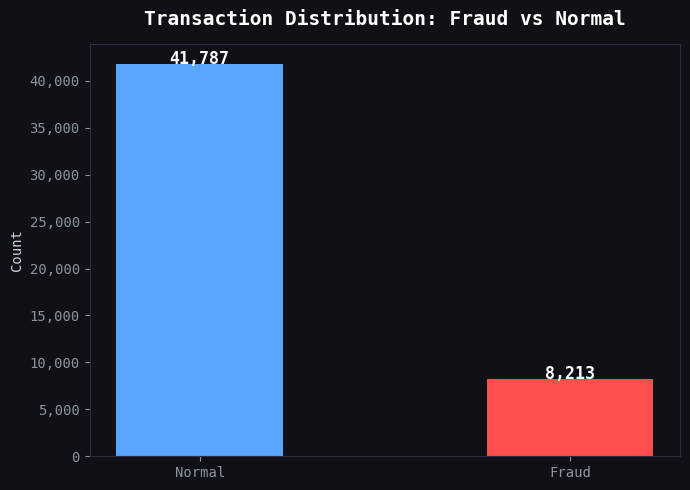

In [11]:
counts = df['is_fraud'].value_counts().sort_index()
labels = ['Normal', 'Fraud']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, counts.values, color=[NORMAL, FRAUD],
              width=0.45, edgecolor='none')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', fontsize=12, fontweight='bold', color='white')
ax.set_title('Transaction Distribution: Fraud vs Normal',
             fontsize=14, fontweight='bold', color='white', pad=14)
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.savefig('visuals/01_fraud_vs_normal.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

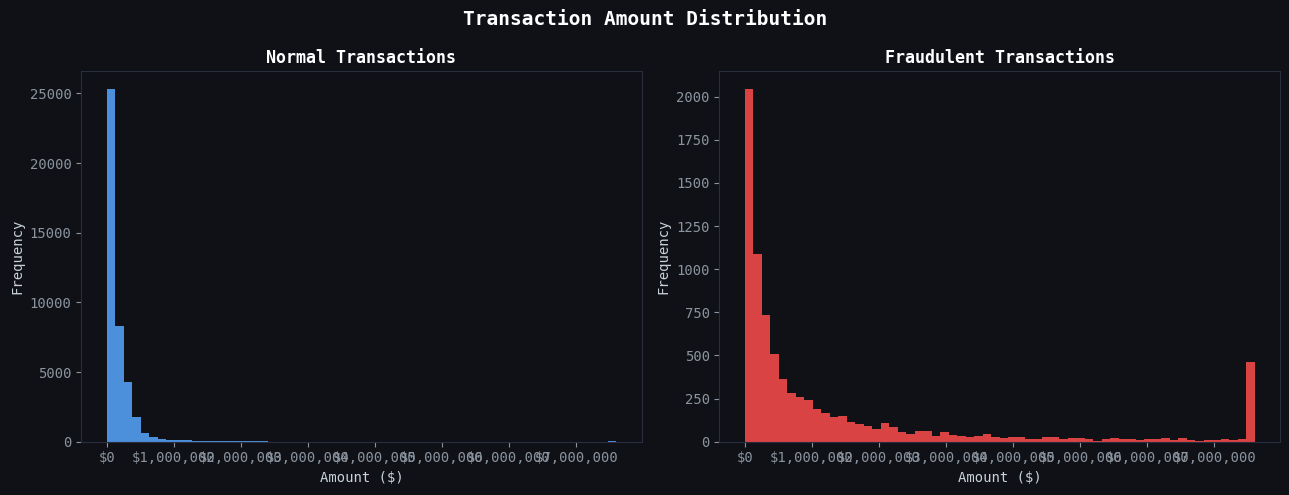

In [12]:
cap = df['amount'].quantile(0.99)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, label, color, mask in zip(
    axes,
    ['Normal Transactions', 'Fraudulent Transactions'],
    [NORMAL, FRAUD],
    [df['is_fraud']==0, df['is_fraud']==1]
):
    ax.hist(df.loc[mask, 'amount'].clip(upper=cap),
            bins=60, color=color, alpha=0.85, edgecolor='none')
    ax.set_title(label, fontsize=12, fontweight='bold', color='white')
    ax.set_xlabel('Amount ($)')
    ax.set_ylabel('Frequency')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
fig.suptitle('Transaction Amount Distribution', fontsize=14,
             fontweight='bold', color='white')
plt.tight_layout()
plt.savefig('visuals/02_amount_distribution.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

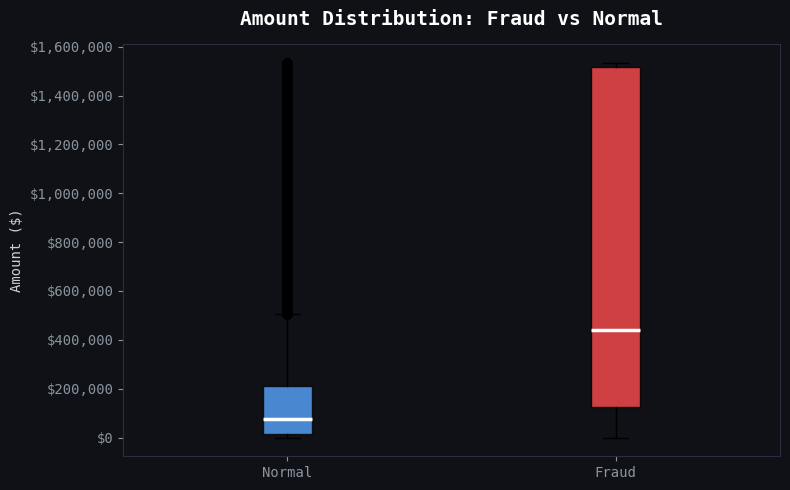

In [13]:
cap = df['amount'].quantile(0.95)
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    [df.loc[df['is_fraud']==0,'amount'].clip(upper=cap),
     df.loc[df['is_fraud']==1,'amount'].clip(upper=cap)],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5)
)
for patch, c in zip(bp['boxes'], [NORMAL, FRAUD]):
    patch.set_facecolor(c); patch.set_alpha(0.8)
ax.set_xticklabels(['Normal', 'Fraud'])
ax.set_title('Amount Distribution: Fraud vs Normal',
             fontsize=14, fontweight='bold', color='white', pad=14)
ax.set_ylabel('Amount ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('visuals/03_boxplot.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

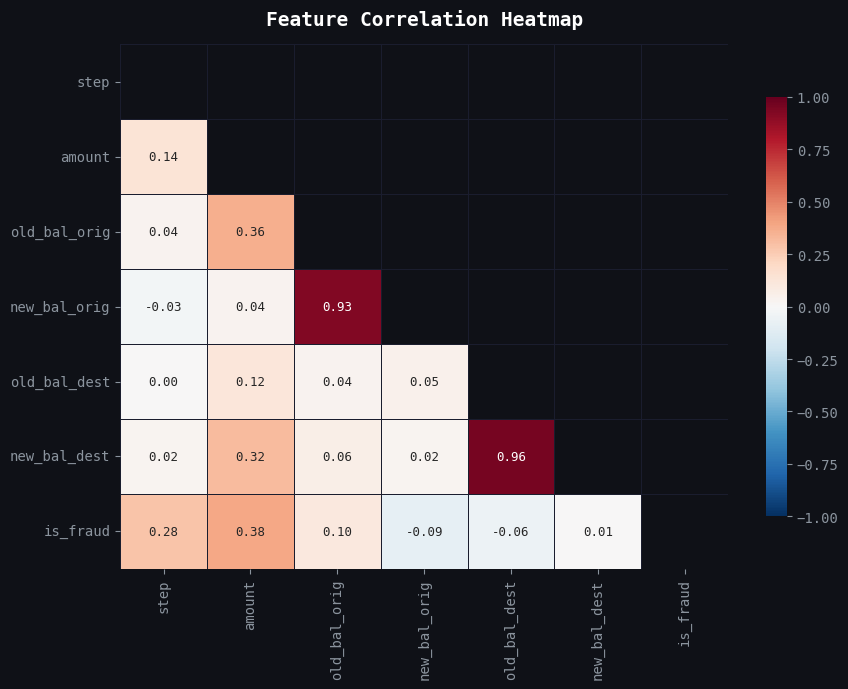

In [14]:
num_cols = ['step','amount','old_bal_orig','new_bal_orig',
            'old_bal_dest','new_bal_dest','is_fraud']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size':9}, linewidths=0.5,
            linecolor='#1a1d2e', cbar_kws={'shrink':0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=14,
             fontweight='bold', color='white', pad=14)
plt.tight_layout()
plt.savefig('visuals/04_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

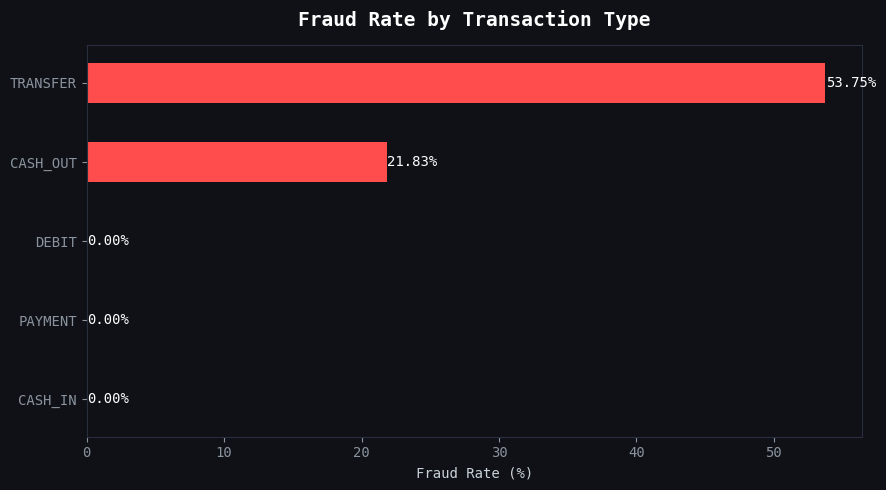

,trans_type,total,fraud_count,fraud_rate
0,CASH_IN,9132,0.0,0.00
1,PAYMENT,14141,0.0,0.00
2,DEBIT,250,0.0,0.00
3,CASH_OUT,18854,4116.0,21.83
4,TRANSFER,7623,4097.0,53.75


In [15]:
type_stats = sql('''
    SELECT
        trans_type,
        COUNT(*)                                   AS total,
        SUM(is_fraud)                              AS fraud_count,
        ROUND(SUM(is_fraud)*100.0/COUNT(*), 2)     AS fraud_rate
    FROM transactions
    GROUP BY trans_type
    ORDER BY fraud_rate ASC
''')

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(type_stats['trans_type'], type_stats['fraud_rate'],
               color=FRAUD, edgecolor='none', height=0.5)
for bar, val in zip(bars, type_stats['fraud_rate']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=10, color='white')
ax.set_title('Fraud Rate by Transaction Type', fontsize=14,
             fontweight='bold', color='white', pad=14)
ax.set_xlabel('Fraud Rate (%)')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.savefig('visuals/05_fraud_by_type.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
display(type_stats)

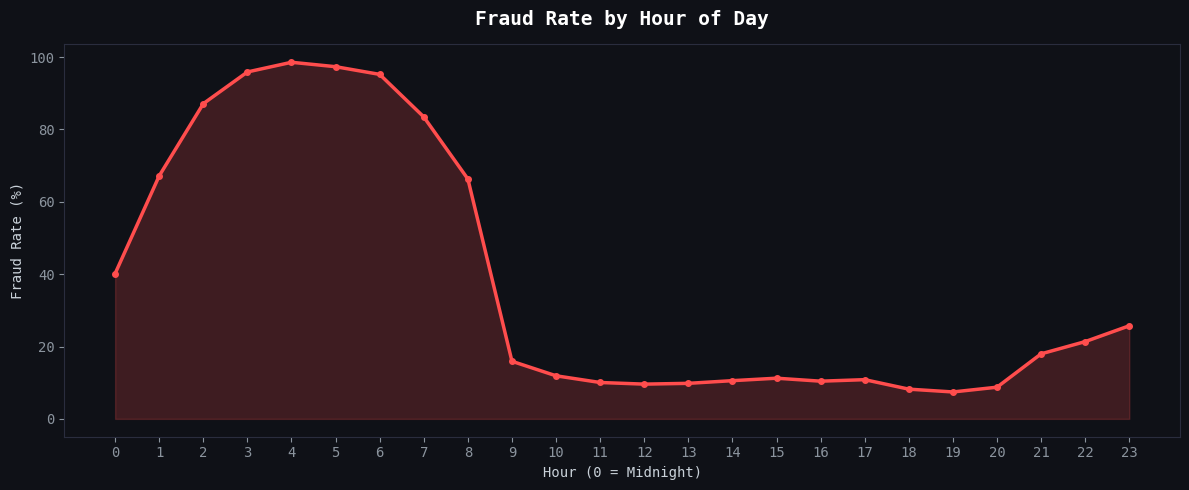

In [16]:
df['hour'] = df['step'] % 24

hourly = sql('''
    SELECT
        step % 24                                  AS hour,
        COUNT(*)                                   AS total,
        SUM(is_fraud)                              AS fraud_count,
        ROUND(SUM(is_fraud)*100.0/COUNT(*), 3)     AS fraud_rate
    FROM transactions
    GROUP BY hour
    ORDER BY hour
''')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly['hour'], hourly['fraud_rate'],
        color=FRAUD, linewidth=2.5, marker='o', markersize=4)
ax.fill_between(hourly['hour'], hourly['fraud_rate'],
                alpha=0.2, color=FRAUD)
ax.set_title('Fraud Rate by Hour of Day', fontsize=14,
             fontweight='bold', color='white', pad=14)
ax.set_xlabel('Hour (0 = Midnight)')
ax.set_ylabel('Fraud Rate (%)')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig('visuals/06_fraud_by_hour.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

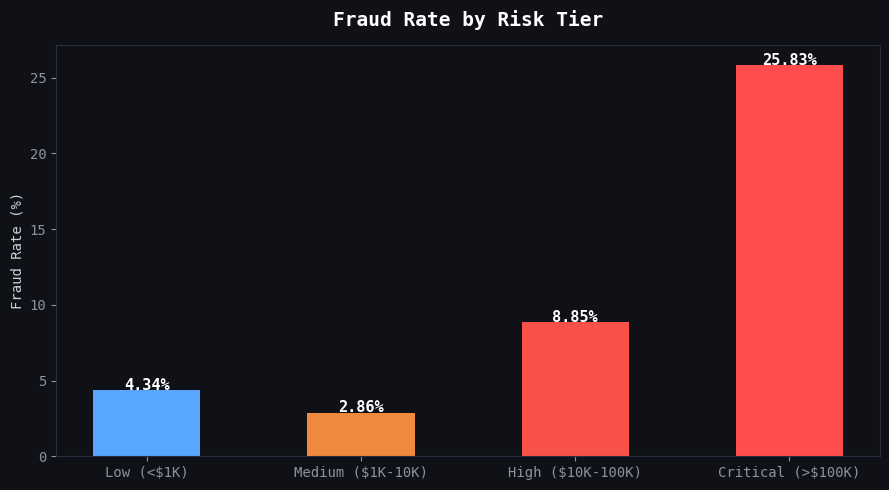

,fraud_count,total,fraud_rate
risk_tier,,,
Low (<$1K),42,967,4.343330
Medium ($1K-10K),220,7684,2.863092
High ($10K-100K),1429,16144,8.851586
Critical (>$100K),6506,25189,25.828735


In [17]:

bins   = [0, 1_000, 10_000, 100_000, float('inf')]
labels = ['Low (<$1K)','Medium ($1K-10K)','High ($10K-100K)','Critical (>$100K)']
df['risk_tier'] = pd.cut(df['amount'], bins=bins, labels=labels)

risk = (
    df.groupby('risk_tier', observed=True)['is_fraud']
    .agg(fraud_count='sum', total='count')
    .assign(fraud_rate=lambda x: x['fraud_count']/x['total']*100)
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [NORMAL, ACCENT, '#f85149', FRAUD]
bars = ax.bar(risk.index, risk['fraud_rate'],
              color=colors, edgecolor='none', width=0.5)
for bar, val in zip(bars, risk['fraud_rate']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
            f'{val:.2f}%', ha='center', fontsize=11,
            fontweight='bold', color='white')
ax.set_title('Fraud Rate by Risk Tier', fontsize=14,
             fontweight='bold', color='white', pad=14)
ax.set_ylabel('Fraud Rate (%)')
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.savefig('visuals/07_risk_tiers.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
display(risk)

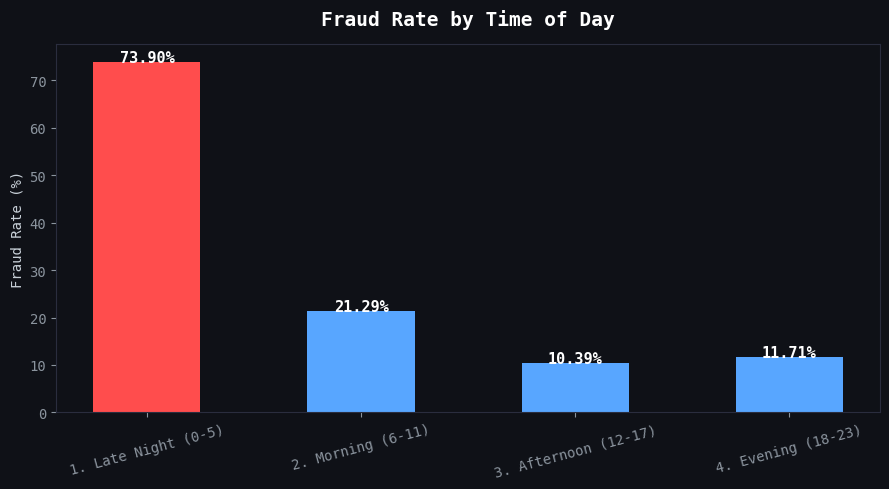

,time_bucket,total,fraud_count,fraud_rate
0,1. Late Night (0-5),2701,1996.0,73.90
1,2. Morning (6-11),9836,2094.0,21.29
2,3. Afternoon (12-17),19988,2077.0,10.39
3,4. Evening (18-23),17475,2046.0,11.71


In [18]:
bucket_stats = sql('''
    SELECT
        CASE
            WHEN step % 24 BETWEEN 0  AND 5  THEN '1. Late Night (0-5)'
            WHEN step % 24 BETWEEN 6  AND 11 THEN '2. Morning (6-11)'
            WHEN step % 24 BETWEEN 12 AND 17 THEN '3. Afternoon (12-17)'
            ELSE                                  '4. Evening (18-23)'
        END AS time_bucket,
        COUNT(*)                               AS total,
        SUM(is_fraud)                          AS fraud_count,
        ROUND(SUM(is_fraud)*100.0/COUNT(*),2)  AS fraud_rate
    FROM transactions
    GROUP BY time_bucket
    ORDER BY time_bucket
''')

max_rate = bucket_stats['fraud_rate'].max()
bar_colors = [FRAUD if v == max_rate else NORMAL
              for v in bucket_stats['fraud_rate']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(bucket_stats['time_bucket'], bucket_stats['fraud_rate'],
              color=bar_colors, edgecolor='none', width=0.5)
for bar, val in zip(bars, bucket_stats['fraud_rate']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{val:.2f}%', ha='center', fontsize=11,
            fontweight='bold', color='white')
ax.set_title('Fraud Rate by Time of Day', fontsize=14,
             fontweight='bold', color='white', pad=14)
ax.set_ylabel('Fraud Rate (%)')
ax.grid(axis='x', visible=False)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('visuals/08_time_of_day.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
display(bucket_stats)

,is_fraud,avg_bal_before,avg_bal_after,avg_balance_drop
0,0,815200.25,838342.48,-23142.24
1,1,1649667.61,192392.63,1457274.97


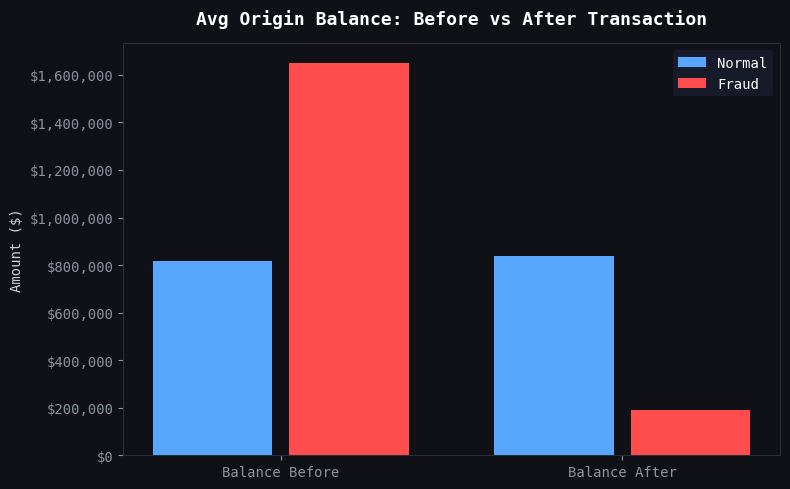

In [19]:
bal_stats = sql('''
    SELECT
        is_fraud,
        ROUND(AVG(old_bal_orig), 2) AS avg_bal_before,
        ROUND(AVG(new_bal_orig), 2) AS avg_bal_after,
        ROUND(AVG(old_bal_orig - new_bal_orig), 2) AS avg_balance_drop
    FROM transactions
    GROUP BY is_fraud
''')
display(bal_stats)

x = ['Balance Before', 'Balance After']
normal_vals = bal_stats.loc[bal_stats['is_fraud']==0, ['avg_bal_before','avg_bal_after']].values[0]
fraud_vals  = bal_stats.loc[bal_stats['is_fraud']==1, ['avg_bal_before','avg_bal_after']].values[0]

xpos = np.arange(len(x))
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(xpos - 0.2, normal_vals, width=0.35, color=NORMAL,
       edgecolor='none', label='Normal')
ax.bar(xpos + 0.2, fraud_vals,  width=0.35, color=FRAUD,
       edgecolor='none', label='Fraud')
ax.set_xticks(xpos); ax.set_xticklabels(x)
ax.set_title('Avg Origin Balance: Before vs After Transaction',
             fontsize=13, fontweight='bold', color='white', pad=14)
ax.set_ylabel('Amount ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.legend(facecolor='#1a1d2e', edgecolor='none', labelcolor='white')
plt.tight_layout()
plt.savefig('visuals/09_balance_anomaly.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

In [20]:
fraud_rate  = df['is_fraud'].mean() * 100
top_type    = type_stats.sort_values('fraud_rate', ascending=False).iloc[0]
peak_hour   = hourly.loc[hourly['fraud_rate'].idxmax()]
top_bucket  = bucket_stats.loc[bucket_stats['fraud_rate'].idxmax()]

print('=' * 58)
print('  KEY ANALYST FINDINGS')
print('=' * 58)
print(f'  Overall fraud rate       : {fraud_rate:.4f}%')
print(f'  Highest-risk txn type    : {top_type["trans_type"]} ({top_type["fraud_rate"]:.1f}% fraud rate)')
print(f'  Peak fraud hour          : {int(peak_hour["hour"]):02d}:00  ({peak_hour["fraud_rate"]:.2f}% rate)')
print(f'  Riskiest time window     : {top_bucket["time_bucket"]}')

if 'Critical (>$100K)' in risk.index and 'Low (<$1K)' in risk.index:
    low  = risk.loc['Low (<$1K)',       'fraud_rate']
    high = risk.loc['Critical (>$100K)','fraud_rate']
    if low > 0:
        print(f'  High-value vs low-value  : {high/low:.1f}× more likely to be fraud')

print()
print('=' * 58)
print('  BUSINESS RECOMMENDATIONS')
print('=' * 58)
print('''
  1. Flag all transactions > $10,000 for secondary review
  2. Enforce step-up auth during peak fraud hour window
  3. Auto-hold TRANSFER / CASH_OUT above risk threshold
  4. Alert when origin balance drops to zero post-txn
  5. Build ML classifier using correlated features
     (old_bal_orig & new_bal_dest show highest correlation)
''')

print('📁 All visuals saved to → /visuals/')

  KEY ANALYST FINDINGS
  Overall fraud rate       : 16.4260%
  Highest-risk txn type    : TRANSFER (53.8% fraud rate)
  Peak fraud hour          : 04:00  (98.56% rate)
  Riskiest time window     : 1. Late Night (0-5)
  High-value vs low-value  : 5.9× more likely to be fraud

  BUSINESS RECOMMENDATIONS

  1. Flag all transactions > $10,000 for secondary review
  2. Enforce step-up auth during peak fraud hour window
  3. Auto-hold TRANSFER / CASH_OUT above risk threshold
  4. Alert when origin balance drops to zero post-txn
  5. Build ML classifier using correlated features
     (old_bal_orig & new_bal_dest show highest correlation)

📁 All visuals saved to → /visuals/
